# 04 - Prompt Bias and Attention Maps

This notebook runs sanity-check inference, analyzes determiner ("the") embedding bias, and visualizes cross-attention map effects.


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Fix SSL certificates on macOS
import os, ssl, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import os
from os.path import join
import torch
import torch as th
import torch.nn.functional as F
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pkl
from tqdm.auto import trange
from contextlib import redirect_stdout
import sys
sys.path.append("/Users/julianali/Desktop/DiffusionInterp/PixArt-alpha")
from diffusion.data.builder import build_dataset, build_dataloader, set_data_root
from diffusion.model.builder import build_model
from diffusion.utils.misc import set_random_seed, read_config, init_random_seed, DebugUnderflowOverflow
sys.path.append("/Users/julianali/Desktop/DiffusionInterp")
from utils.cv2_eval_utils import evaluate_pipeline_on_prompts, print_evaluation_summary
from utils.relation_shape_dataset_lib import ShapesDataset
from utils.variance_partition_with_effects import variance_partition_with_effects
from utils.pixart_sampling_utils import pipeline_inference_custom, \
    PixArtAlphaPipeline_custom, PixArtAlphaPipeline_custom_CLIP
from utils.pixart_utils import state_dict_convert, load_pixart_ema_into_transformer
from utils.pixart_utils import construct_diffuser_pipeline_from_config, PixArt_model_configs
from utils.text_encoder_control_lib import RandomEmbeddingEncoder_wPosEmb
from utils.image_utils import pil_images_to_grid
from utils.attention_map_store_utils import replace_attn_processor, AttnProcessor2_0_Store, PixArtAttentionVisualizer_Store
from utils.cv2_eval_utils import find_classify_object_masks
from diffusers import AutoencoderKL, Transformer2DModel, PixArtAlphaPipeline, DPMSolverMultistepScheduler
from transformers import T5Tokenizer, T5EncoderModel

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = "cuda"
    compute_dtype = torch.float16
elif torch.backends.mps.is_available():
    device = "mps"
    compute_dtype = torch.float32
else:
    device = "cpu"
    compute_dtype = torch.float32
print(f"Using device: {device}, compute dtype: {compute_dtype}")

def saveallforms(figdir, fname, figh=None, fmts=("png", "pdf")):
    """Local replacement for circuit_toolkit.plot_utils.saveallforms"""
    os.makedirs(figdir, exist_ok=True)
    fig = figh if figh is not None else plt.gcf()
    for fmt in fmts:
        fig.savefig(os.path.join(figdir, f"{fname}.{fmt}"), bbox_inches='tight', dpi=150)

/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/c

Using device: mps, compute dtype: torch.float32


In [3]:
from itertools import product
def generate_all_prompt_collection(spatial_phrases, 
                               prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",):
    color_list = ['red', 'blue']
    shape_list = ['square', 'triangle', 'circle']
    prompt_collection = []
    scene_info_collection = []
    for color1, color2 in product(color_list, color_list):
        if color1 == color2:      # skip same‐color pairs
            continue
        for shape1, shape2 in product(shape_list, shape_list):
            if shape1 == shape2:
                continue
            for spatial_relationship, rel_text_collection in spatial_phrases.items():
                if spatial_relationship in ["in_front", "behind"]:
                    continue
                for rel_text in rel_text_collection:
                    prompt = prompt_template.format(color1=color1, shape1=shape1, rel_text=rel_text, color2=color2, shape2=shape2)
                    scene_info = {
                        "color1": color1,
                        "shape1": shape1,
                        "color2": color2,
                        "shape2": shape2,
                        "spatial_relationship": spatial_relationship
                    }
                    prompt_collection.append(prompt)
                    scene_info_collection.append(scene_info)
    return prompt_collection, scene_info_collection

In [4]:
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from experimental_scripts.generalization_profile_eval_cli import precompute_embeddings
def find_shape_index(tokens, shape):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = shape.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = shape.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

def find_word_index(tokens, word):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = word.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = word.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

## Section A - Environment Setup and Model Loading

Loads dependencies, resolves project paths, selects device/dtype, and builds the PixArt mini pipeline from checkpoint so later analysis cells can reuse a single initialized model.

### Suggested Notebook Split (Recommended)

For maintainability and faster Colab runs, this workflow is best split into separate notebooks:

1. **`01_setup_and_head_discovery.ipynb`** - environment setup, embedding cache, full head screening, and core visual diagnostics.
2. **`02_ablation_and_causality.ipynb`** - single/multi-head ablations, temporal/step ablations, and downstream reader tracing.
3. **`03_identifiability_and_variance_partition.ipynb`** - identifiability curves, norm tracking, and variance-partition evolution.
4. **`04_prompt_bias_and_attention_maps.ipynb`** - determiner ("the") bias analyses and cross-attention map comparisons.

Each notebook should begin by loading shared utilities and cached artifacts from `results/` to avoid recomputation.

In [ ]:
import time, gc, psutil

def mem_gb():
    m = psutil.virtual_memory()
    return m.available / (1024**3), m.used / (1024**3)

def mem_check(label, min_gb=2.0):
    avail, used = mem_gb()
    print(f"  [{label}] RAM: {avail:.1f} GB free, {used:.1f} GB used")
    if avail < min_gb:
        raise MemoryError(
            f"Only {avail:.1f} GB free — need at least {min_gb} GB. "
            f"Close other apps (browsers, Slack, etc.) and retry."
        )

_t0 = time.time()
mem_check("start", min_gb=3.0)

model_run_name = "objrel_T5_DiT_mini_pilot"
ckpt_name = "epoch_4000_step_160000.pth"
savedir = f"/Users/julianali/Desktop/DiffusionInterp/results/{model_run_name}"
config = read_config(join(savedir, 'config.py'))
print(f"[1/5] Config loaded — Model: {config.model}  ({time.time()-_t0:.1f}s)")

# Build ONLY the mini transformer (~100MB, not the full XL pipeline)
print("[2/5] Building DiT-mini transformer...")
from utils.pixart_utils import construct_diffuser_transformer_from_config
transformer = construct_diffuser_transformer_from_config(config)
print(f"       Transformer built ({time.time()-_t0:.1f}s)")
mem_check("after transformer")

# Load checkpoint into transformer, then free the checkpoint
print("[3/5] Loading trained checkpoint...")
ckptdir = join(savedir, "checkpoints")
ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
load_pixart_ema_into_transformer(transformer, ckpt['state_dict_ema'])
del ckpt; gc.collect()
print(f"       Checkpoint loaded ({time.time()-_t0:.1f}s)")
mem_check("after checkpoint")

# Load VAE directly from Stability AI (~300MB, NOT from the huge PixArt-XL bundle)
print("[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema", torch_dtype=compute_dtype)
print(f"       VAE loaded ({time.time()-_t0:.1f}s)")
mem_check("after VAE")

# Assemble pipeline manually — this avoids downloading PixArt-XL-2-512x512 (~10GB+)
print("[5/5] Assembling pipeline (no large downloads)...")
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
scheduler = DPMSolverMultistepScheduler()
pipeline = PixArtAlphaPipeline_custom(
    transformer=transformer,
    vae=vae,
    scheduler=scheduler,
    tokenizer=tokenizer,
    text_encoder=None,
)

# Move lightweight components to device
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
pipeline.vae = pipeline.vae.to(device=device, dtype=compute_dtype)

gc.collect()
avail, used = mem_gb()
print(f"\nDone! Pipeline on {device} ({time.time()-_t0:.1f}s)")
print(f"RAM: {avail:.1f} GB free, {used:.1f} GB used")

  [start] RAM: 4.5 GB free, 7.4 GB used
[1/5] Config loaded — Model: PixArt_mini_2  (0.0s)
[2/5] Building DiT-mini transformer...
       Transformer built (0.0s)
  [after transformer] RAM: 4.5 GB free, 7.4 GB used
[3/5] Loading trained checkpoint...
       Checkpoint loaded (0.3s)
  [after checkpoint] RAM: 4.4 GB free, 7.3 GB used
[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...


/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


       VAE loaded (0.6s)
  [after VAE] RAM: 4.3 GB free, 7.2 GB used
[5/5] Assembling pipeline (no large downloads)...

Done! Pipeline on mps (1.4s)
RAM: 4.1 GB free, 7.5 GB used


In [6]:
# Load pre-computed T5 embeddings from cache.
# If no cache exists, run the script in a SEPARATE PROCESS so T5 never enters this notebook.
import subprocess

cache_path = join(savedir, "t5_embedding_cache.pt")

if not os.path.exists(cache_path):
    avail, used = mem_gb()
    print(f"RAM before subprocess: {avail:.1f} GB free")
    if avail < 6.0:
        print(f"\n*** WARNING: Only {avail:.1f} GB free. The T5 subprocess needs ~6GB. ***")
        print("*** Close browsers, Slack, and other apps, then re-run this cell. ***\n")
    
    print("No embedding cache found. Running precomputation in a separate process...")
    print("(T5-XXL loads in a subprocess — this notebook's memory is unaffected)")
    print("This takes a few minutes the first time.\n")
    
    result = subprocess.run(
        [sys.executable, "/Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"],
    )
    if result.returncode != 0:
        raise RuntimeError(
            "Embedding precomputation failed!\n"
            "Try: 1) Close all other apps  2) Re-run this cell\n"
            "Or run the script directly in terminal:\n"
            f"  {sys.executable} /Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"
        )

print(f"Loading cached embeddings from {cache_path}...")
_cache = torch.load(cache_path, map_location="cpu", weights_only=False)
embedding_allrel_allobj = _cache["embedding_allrel_allobj"]
del _cache; gc.collect()
avail, _ = mem_gb()
print(f"Loaded {len(embedding_allrel_allobj)} embeddings. ({avail:.1f} GB free)")

Loading cached embeddings from /Users/julianali/Desktop/DiffusionInterp/results/objrel_T5_DiT_mini_pilot/t5_embedding_cache.pt...
Loaded 1057 embeddings. (4.1 GB free)


## Section B - Build/Load Embedding Cache and Token Features

Creates (or loads) cached T5 embeddings, extracts token-level vectors for objects/relations, and projects them into model space for head-alignment and downstream causal analysis.

In [7]:
# Extract word vectors from the pre-computed cached embeddings
dataset_tmp = ShapesDataset(num_images=10000)
prompt_collection_all, scene_info_collection_all = generate_all_prompt_collection(dataset_tmp.spatial_phrases,
                                prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",)
prompt_scene_info_all_df = pd.DataFrame(scene_info_collection_all)
prompt_scene_info_all_df["prompt"] = prompt_collection_all

wordvec_obj1_col = []
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    token_ids = tokenized['input_ids'][0]
    tokens = [pipeline.tokenizer.decode([token_id]) for token_id in token_ids]
    
    shape1_mask_idx = find_shape_index(tokens, row.shape1)
    shape2_mask_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    if shape1_mask_idx is None or shape2_mask_idx is None:
        print(f"Prompt: {row.prompt}")
        print(f"Shape1 ({row.shape1}) at index: {shape1_mask_idx}")
        print(f"Shape2 ({row.shape2}) at index: {shape2_mask_idx}")
        raise ValueError("Shape index not found")
    wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
    wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
    wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
print(f"Extracted word vectors: obj1={wordvec_obj1_mat.shape}, obj2={wordvec_obj2_mat.shape}")
print(f"Projected: obj1_proj={wordvec_obj1_mat_proj.shape}, obj2_proj={wordvec_obj2_mat_proj.shape}")

Extracted word vectors: obj1=torch.Size([264, 4096]), obj2=torch.Size([264, 4096])
Projected: obj1_proj=torch.Size([264, 384]), obj2_proj=torch.Size([264, 384])


In [8]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
             "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
             "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.753982
Total R² (all features): 0.7540


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,247,4287.382813,517.440110,0.120689,5.174401e+02,1.206890e-01,3.291159e-01,0.009901
1,color2shape2,6,5,247,4287.382813,2478.810885,0.578164,5.403549e+01,1.260338e-02,4.873296e-02,0.009901
2,color1shape1,6,5,247,4287.382813,1051.531256,0.245262,2.134541e+01,4.978657e-03,1.983557e-02,0.514851
3,shape2,3,2,247,4287.382813,2204.805622,0.514254,1.709012e-13,3.986142e-17,1.620266e-16,1.000000
4,color1,2,1,247,4287.382813,200.811887,0.046838,8.054627e-14,1.878682e-17,7.636365e-17,1.000000
5,color2,2,1,247,4287.382813,200.811887,0.046838,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
6,shape1,3,2,247,4287.382813,810.216076,0.188977,-4.825689e-13,-1.125556e-16,-4.575099e-16,1.000000


In [9]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj1_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
             "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.757099
Total R² (all features): 0.7571


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,249,3454.200772,275.282371,0.079695,2.752824e+02,7.969495e-02,2.470428e-01,0.009901
1,shape2,3,2,249,3454.200772,703.267542,0.203598,1.897958e+02,5.494639e-02,1.844784e-01,0.009901
2,color1shape1,6,5,249,3454.200772,2150.094347,0.622458,6.427153e+01,1.860677e-02,7.115195e-02,0.009901
3,color2,2,1,249,3454.200772,226.763259,0.065649,1.121765e-12,3.247538e-16,1.336981e-15,1.000000
4,shape1,3,2,249,3454.200772,1859.059553,0.538203,8.298863e-13,2.402542e-16,9.891042e-16,1.000000


In [10]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.749004
Total R² (all features): 0.7490


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color2shape2,6,5,249,4287.382813,2478.810885,0.578164,1883.608754,0.439338,0.636413,0.009901
1,spatial_relationship,8,7,249,4287.382813,517.440110,0.120689,517.440110,0.120689,0.324707,0.009901
2,shape1,3,2,249,4287.382813,810.216076,0.188977,215.013945,0.050150,0.166531,0.009901


In [11]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

shape2, T5 embedding, caption projection
Total R2 (all features): 0.619995
Total R² (all features): 0.6200


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color2shape2,6,5,249,11125.028957,3809.018882,0.342383,3340.579401,0.300276,0.441400,0.009901
1,spatial_relationship,8,7,249,11125.028957,2201.632767,0.197899,2201.632767,0.197899,0.342443,0.009901
2,shape1,3,2,249,11125.028957,1355.255459,0.121820,886.815978,0.079714,0.173397,0.009901


## Section C - Head Screening (Alignment Scan)

Scores all cross-attention heads by alignment to relation directions and saves a ranked table used to pick candidate relation heads for visualization and ablation.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def ramp_alignment_metrics(M, dvec, eps=1e-12):
    """
    Returns:
      cosine     : [-1, 1] alignment with spatial direction (scale-free)
      projection : signed magnitude of alignment (units of M)
    """
    H, W = M.shape
    d = np.array(dvec)
    d = d / np.linalg.norm(d)
    
    # coordinate grid
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    X, Y = np.meshgrid(xs, ys)

    # ramp template
    T = d[0] * X + d[1] * Y
    T = T - T.mean()                      # remove DC (important!)
    T_norm = np.linalg.norm(T) + eps
    T_unit = T / T_norm                   # unit template

    # centered map
    # A = M.astype(float)
    A = M - M.mean()
    A_norm = np.linalg.norm(A) + eps

    # (1) signed projection magnitude
    projection = np.sum(A * T / T_norm)

    # (2) cosine / correlation
    cosine = projection / A_norm

    return dict(
        cosine=cosine,
        projection=projection,
        energy=A_norm,
        template_norm=T_norm,
    )


def visualize_direction_vectors(H=8, W=8):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    # Visualize the template ramps in 2x4 subplots
    H, W = 8, 8  # set the dimensions of the grid (adjust if appropriate)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for idx, (name, dvec) in enumerate(direction_vector.items()):
        xs = np.linspace(-1, 1, W)
        ys = np.linspace(-1, 1, H)
        X, Y = np.meshgrid(xs, ys)
        d = np.array(dvec)
        d = d / np.linalg.norm(d)
        T = d[0] * X + d[1] * Y
        T = T - T.mean()
        
        ax = axes[idx // 4, idx % 4]
        im = ax.imshow(T, cmap='coolwarm')
        ax.set_title(name)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# visualize_direction_vectors()
# inner_prod_mat[:, i_word:i_word+1].view(8, 8)
# plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
# plt.title(f"{levels_map['spatial_relationship'][i_word]}")
def eval_ramp_alignment_all(inner_prod_mat, spatial_relationship_levels, eps=1e-12):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    i_word = 1
    align_dict_list = []
    for i_word in range(len(spatial_relationship_levels)):
        rel_name = spatial_relationship_levels[i_word]
        dvec = direction_vector[rel_name]
        align_dict = ramp_alignment_metrics(inner_prod_mat[:, i_word:i_word+1].view(8, 8).detach().cpu().numpy(), dvec, eps=1e-12)
        align_dict["rel_name"] = rel_name
        align_dict["dvec"] = (dvec[0], dvec[1])
        align_dict["dir_idx"] = i_word
        align_dict_list.append(align_dict)
    # align_dict_list
    align_df = pd.DataFrame(align_dict_list)
    return align_df

In [13]:
from utils.pixart_pos_embed import get_2d_sincos_pos_embed

In [14]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
print(f"Model: {config.model} — {layer_num} layers, {head_num} heads, hidden_size={hidden_size}, head_dim={head_dim}")
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads = pd.concat(align_df_list)

Model: PixArt_mini_2 — 6 layers, 6 heads, hidden_size=384, head_dim=64


0it [00:00, ?it/s]

36it [00:00, 338.77it/s]


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
figroot = "/Users/julianali/Desktop/DiffusionInterp/Figures/DiT_T5_attn_head_finding"
figdir = join(figroot, model_run_name)
os.makedirs(figdir, exist_ok=True)

Top spatial heads (by |cosine| > 0.7):
  Layer 0, Head 0: cosine=0.97, proj=88.1, energy=91
  Layer 1, Head 2: cosine=-0.98, proj=-42.8, energy=44
  Layer 2, Head 0: cosine=-0.78, proj=-12.9, energy=16
  Layer 2, Head 1: cosine=-0.78, proj=-16.9, energy=21
  Layer 2, Head 2: cosine=-0.92, proj=-18.6, energy=20
  Layer 2, Head 5: cosine=-0.77, proj=-9.3, energy=12
  Layer 3, Head 4: cosine=-0.83, proj=-7.8, energy=9
  Layer 3, Head 5: cosine=-0.75, proj=-6.0, energy=8


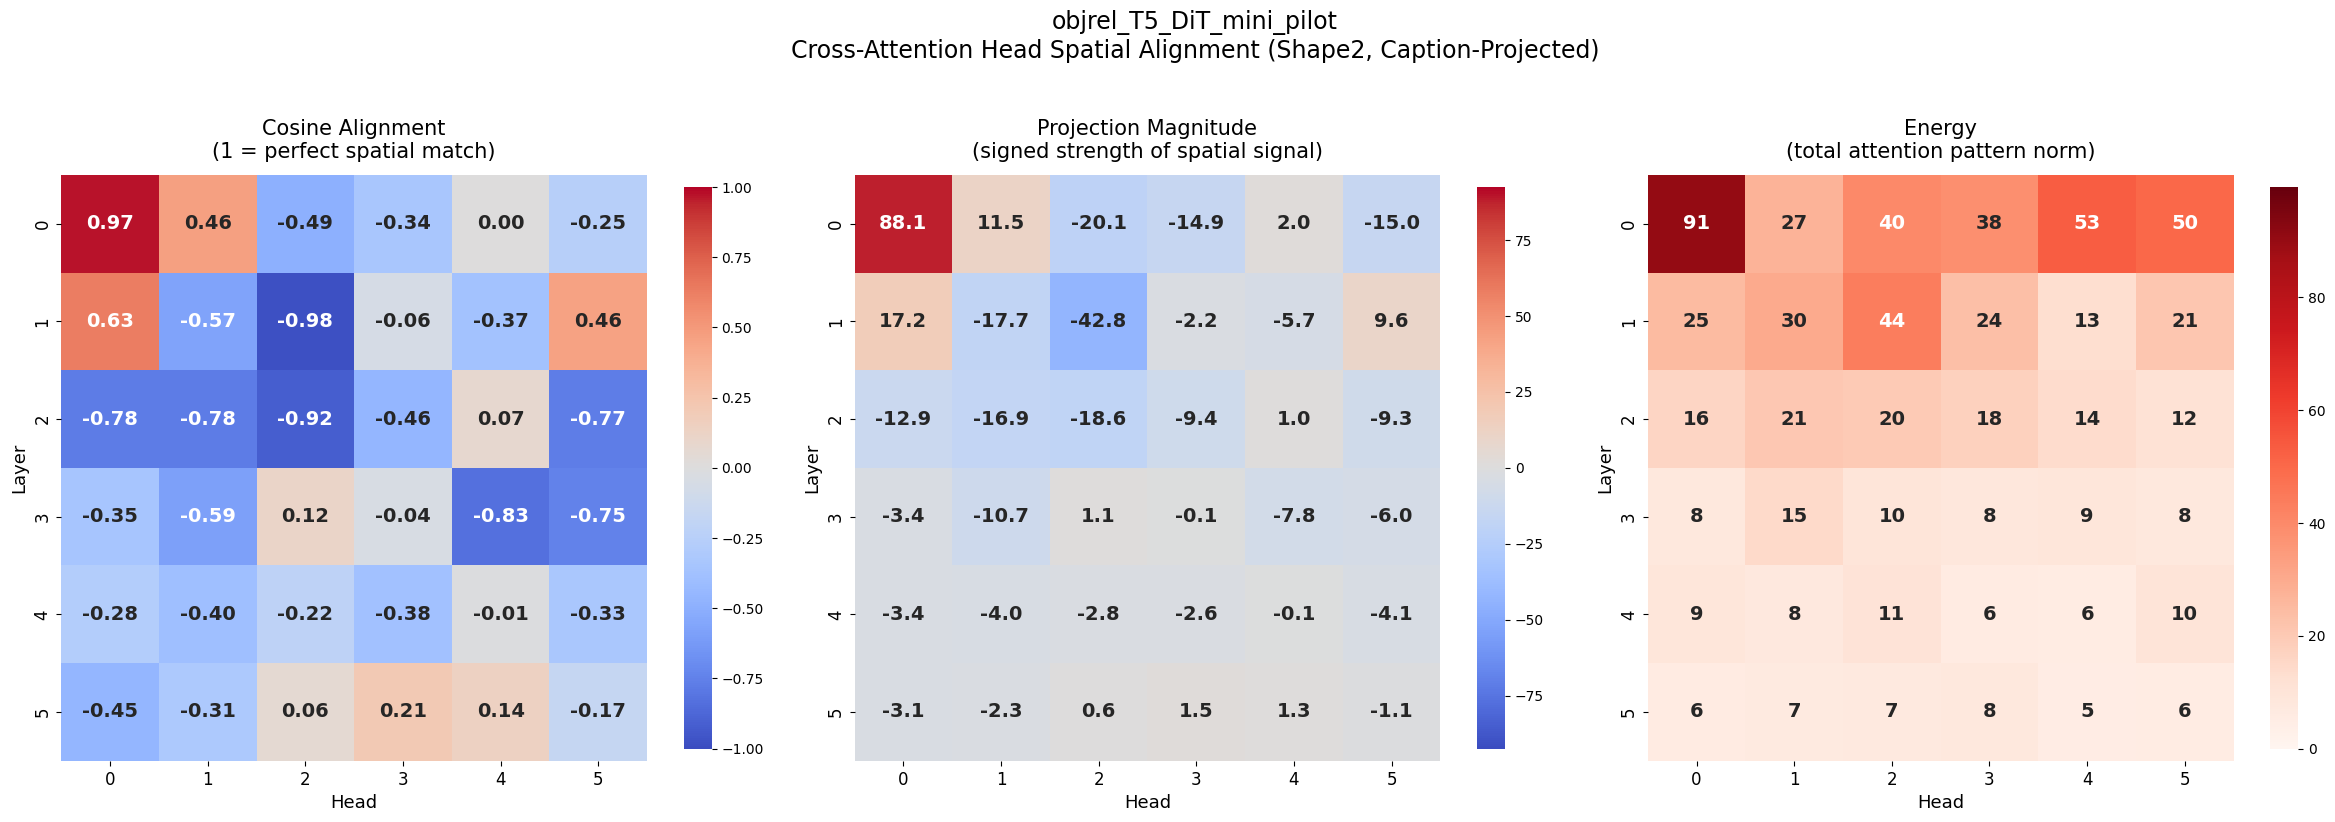

In [16]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape2_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

# Use data-driven color limits for projection so weak heads aren't washed out
proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

# Highlight top spatial heads
print("Top spatial heads (by |cosine| > 0.7):")
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        l, h = row.name
        print(f"  Layer {l}, Head {h}: cosine={row['cosine']:.2f}, proj={row['projection']:.1f}, energy={row['energy']:.0f}")

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape2, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape2_MLP_proj_rel_factor")
plt.show()

### Section C.1 - Shape1/Object1 Alignment Scan

Repeats the head-alignment computation for object1 (shape1) features to compare whether heads encode object identity vs spatial relation.

In [17]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df_S1, intercept_S1, effect_vecs_S1, levels_map_S1, R2_total_S1 = variance_partition_with_effects(wordvec_obj1_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
            #  "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df_S1

shape2, T5 embedding, caption projection
Total R2 (all features): 0.670111
Total R² (all features): 0.6701


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color1shape1,6,5,249,10202.900793,4351.159422,0.426463,3799.699106,0.372414,0.530275,0.009901
1,spatial_relationship,8,7,249,10202.900793,1668.141067,0.163497,1668.141067,0.163497,0.331377,0.009901
2,shape2,3,2,249,10202.900793,1369.238377,0.134201,817.778060,0.080152,0.195472,0.009901


In [18]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs_S1["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_S1["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads_S1 = pd.concat(align_df_list)

0it [00:00, ?it/s]

36it [00:00, 275.40it/s]


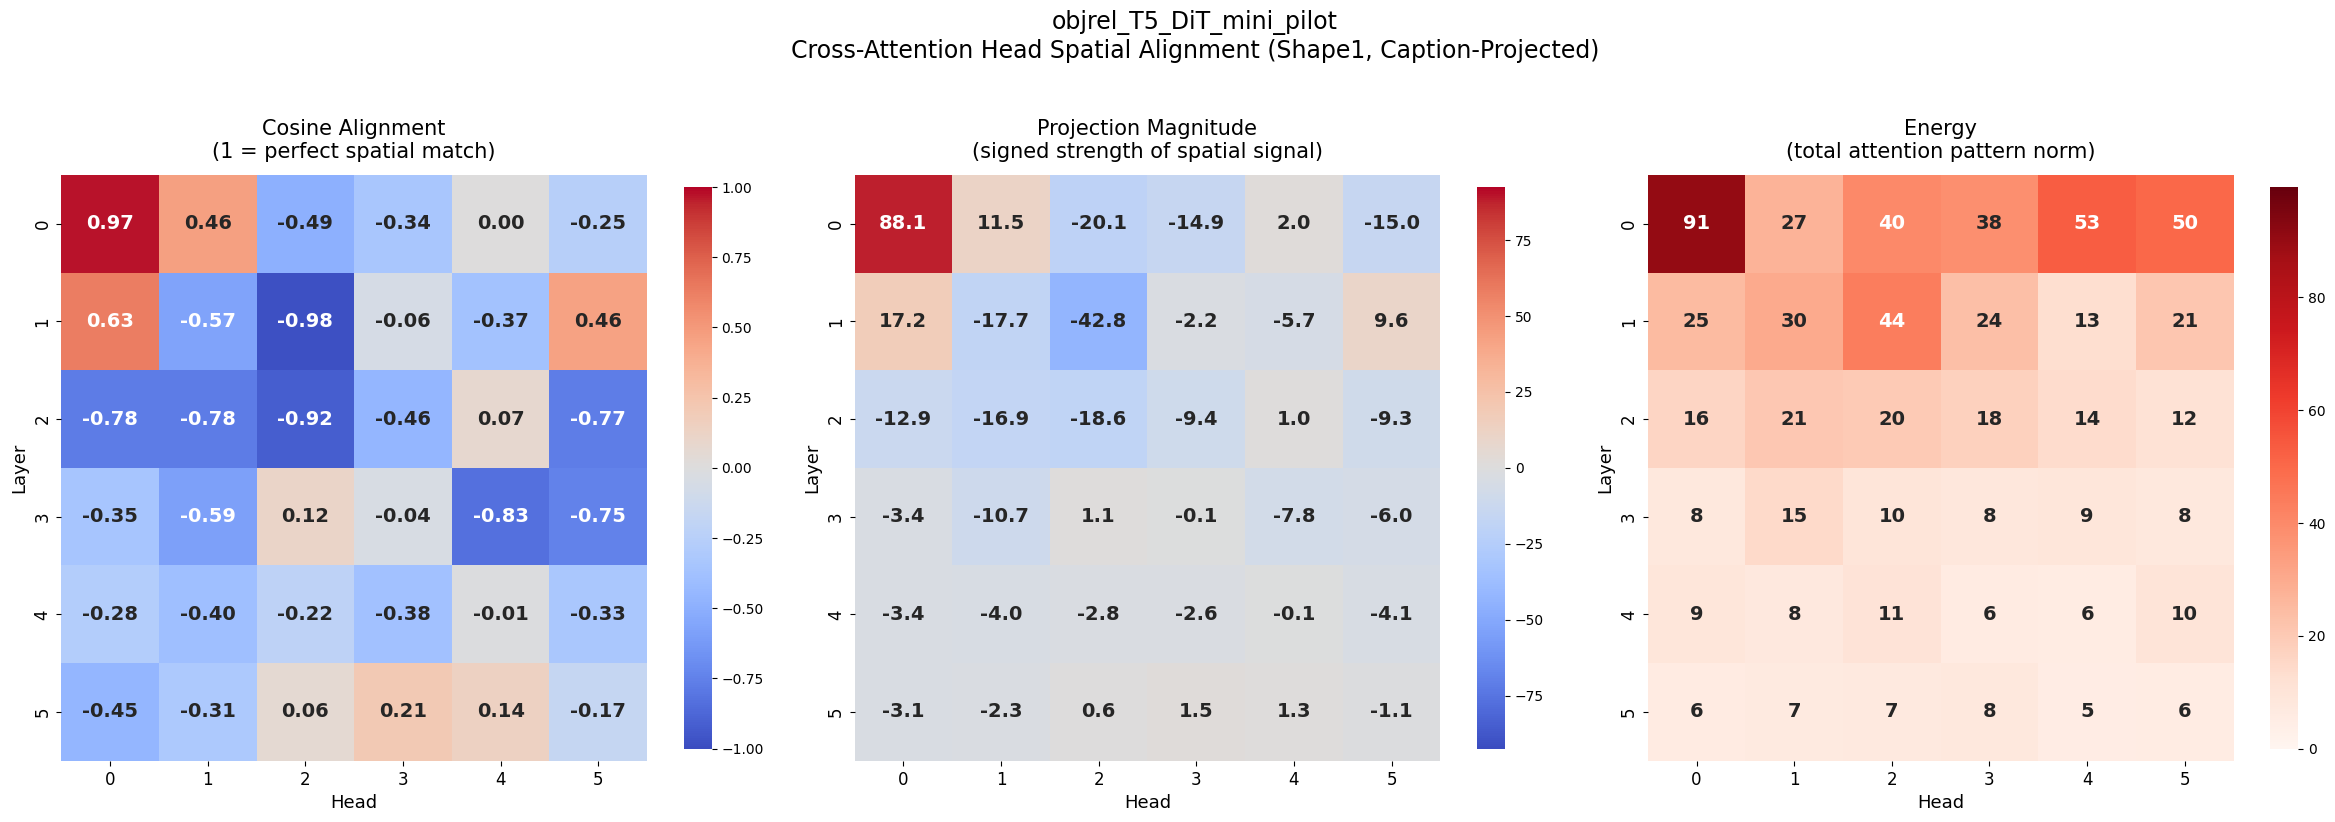

In [19]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape1_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape1, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape1_MLP_proj_rel_factor")
plt.show()

### Section C.2 - Selective Head Visualization

Generates focused plots for selected high-value heads/layers so you can quickly inspect spatial ramp structure without scanning all heads.

Text(0.5, 0.98, 'objrel_T5_DiT_mini_pilot\nL0H0 pos embed inner product with spatial relation factors in Caption Projection')

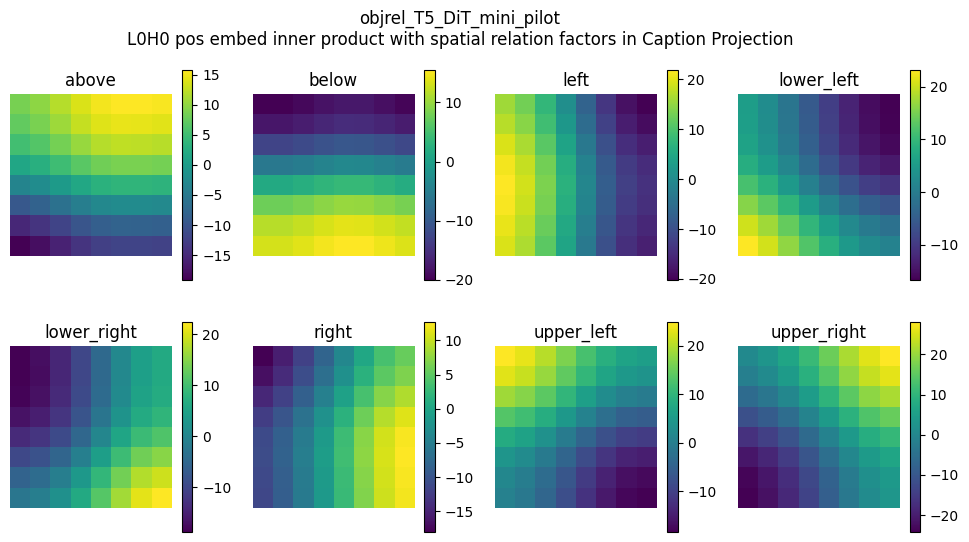

In [20]:
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
# Pick a layer/head to inspect — update after seeing the heatmaps above
layer_idx, head_idx = 0,0
target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()
for i_word in range(len(effect_vecs["spatial_relationship"])):
    plt.sca(axs[i_word])
    attn_score = inner_prod_mat[:, i_word:i_word+1]
    plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
    plt.title(f"{levels_map['spatial_relationship'][i_word]}")
    plt.axis("off")
    plt.colorbar()
plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with spatial relation factors in Caption Projection")

In [21]:
from utils.pixart_utils import PixArt_model_configs
def compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, feature_vecs, levels_names=None, 
                                   model_run_name="model", device=device, visualize=True):
    """
    Visualize the inner product between 2D positional embeddings and target effect vectors for specified head/layer.
    """
    transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
    hidden_size = transformer_config["hidden_size"]
    head_num = transformer_config["num_heads"]
    layer_num = transformer_config["depth"]
    base_size = 16 // 2
    head_dim = hidden_size // head_num

    target_embedding_direction = feature_vecs[:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
    if visualize:
        num_levels = len(feature_vecs)
        nrows, ncols = (2, 4) if num_levels == 8 else (1, num_levels)
        fig, axs = plt.subplots(nrows, ncols, figsize=(12, 6))
        axs = axs.flatten() if hasattr(axs, "flatten") else [axs]

        for i_word in range(num_levels):
            plt.sca(axs[i_word])
            attn_score = inner_prod_mat[:, i_word:i_word+1]
            plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
            if levels_names is not None:
                plt.title(f"{levels_names[i_word]}")
            else:
                plt.title(f"{i_word}")
            plt.axis("off")
            plt.colorbar()
        plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with {len(feature_vecs)} factors in Caption Projection")
        plt.tight_layout()
        plt.show()
    else:
        fig = None
    return inner_prod_mat, fig

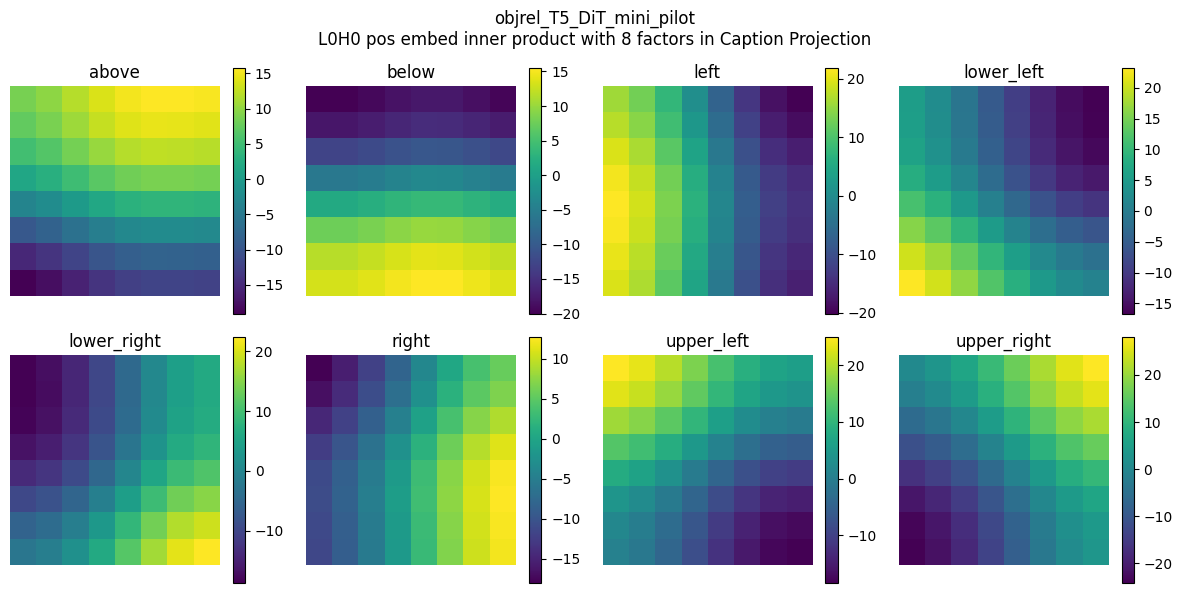

In [22]:
# Example: inspect the strongest spatial head
inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, 0, 0, 
                                 effect_vecs["spatial_relationship"], 
                                 levels_names=levels_map["spatial_relationship"], 
                                 model_run_name=model_run_name, 
                                 device=device, visualize=True);

Visualizing 8 top spatial heads: [(0, 0), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 4), (3, 5)]



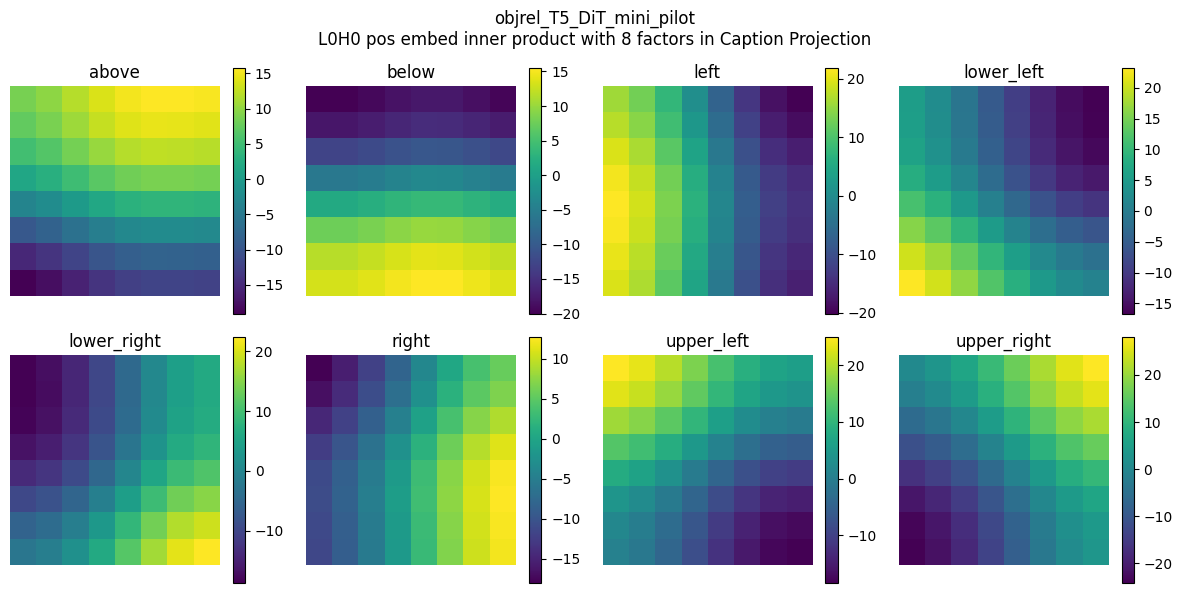

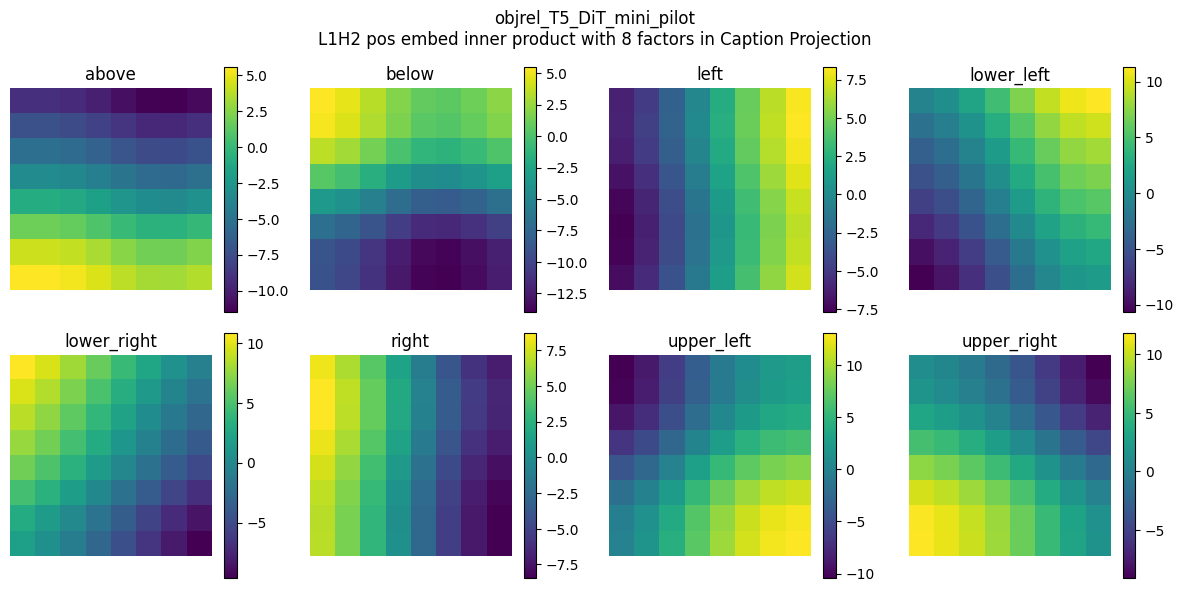

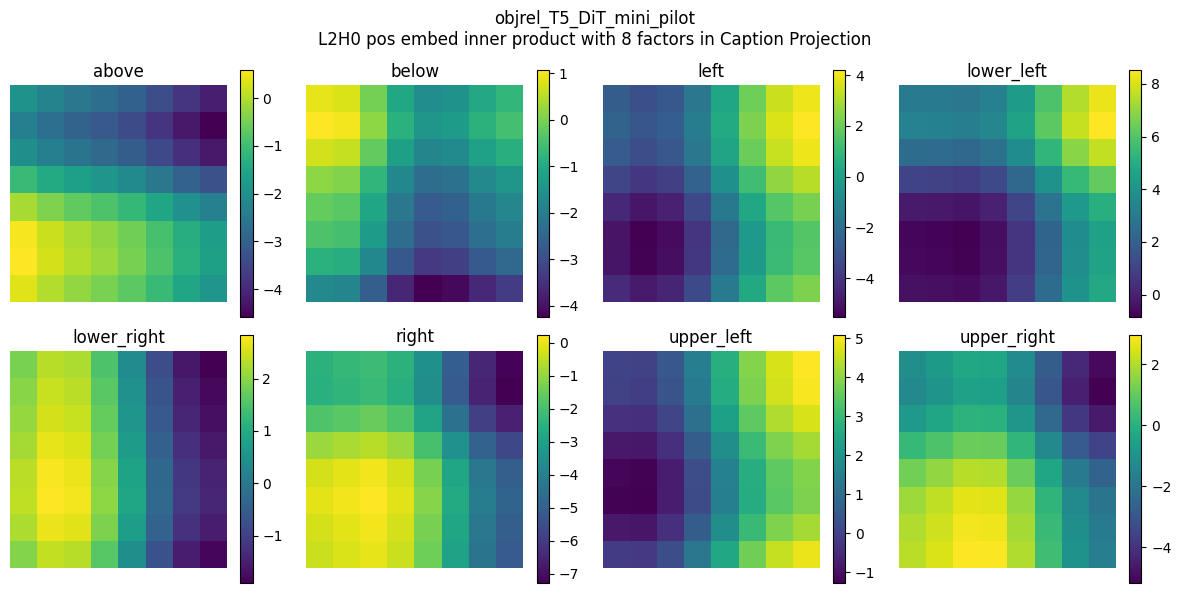

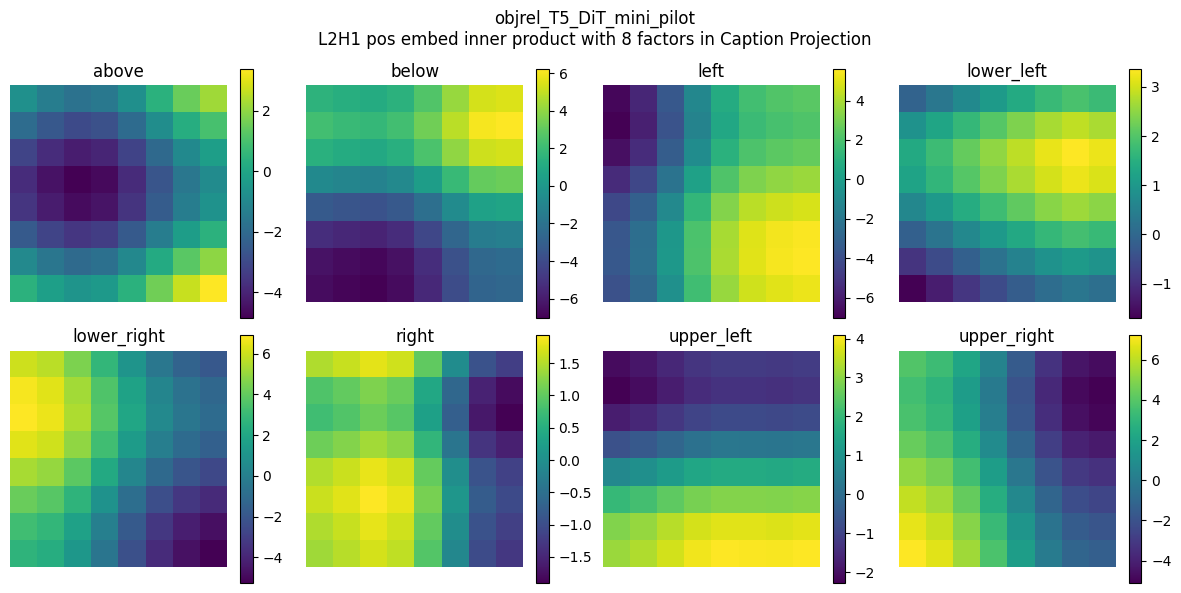

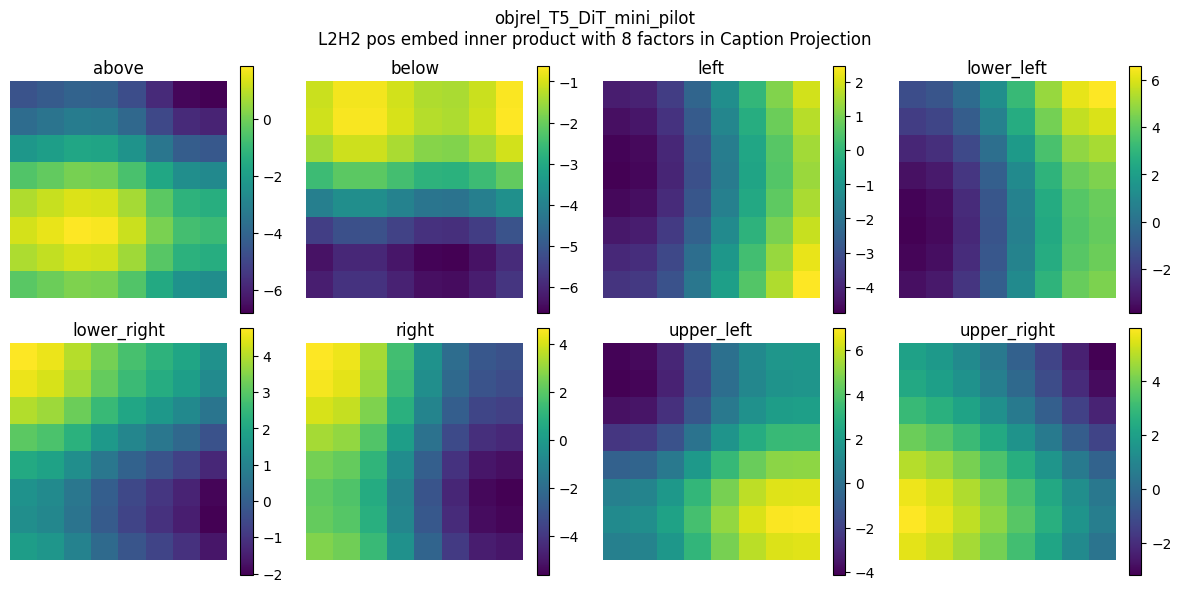

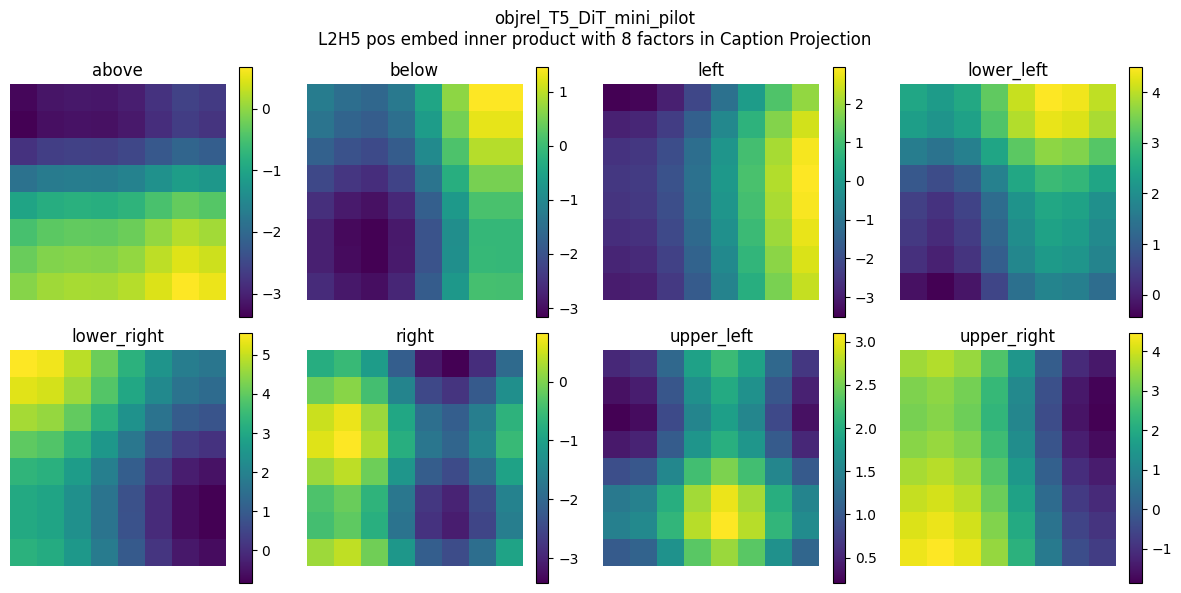

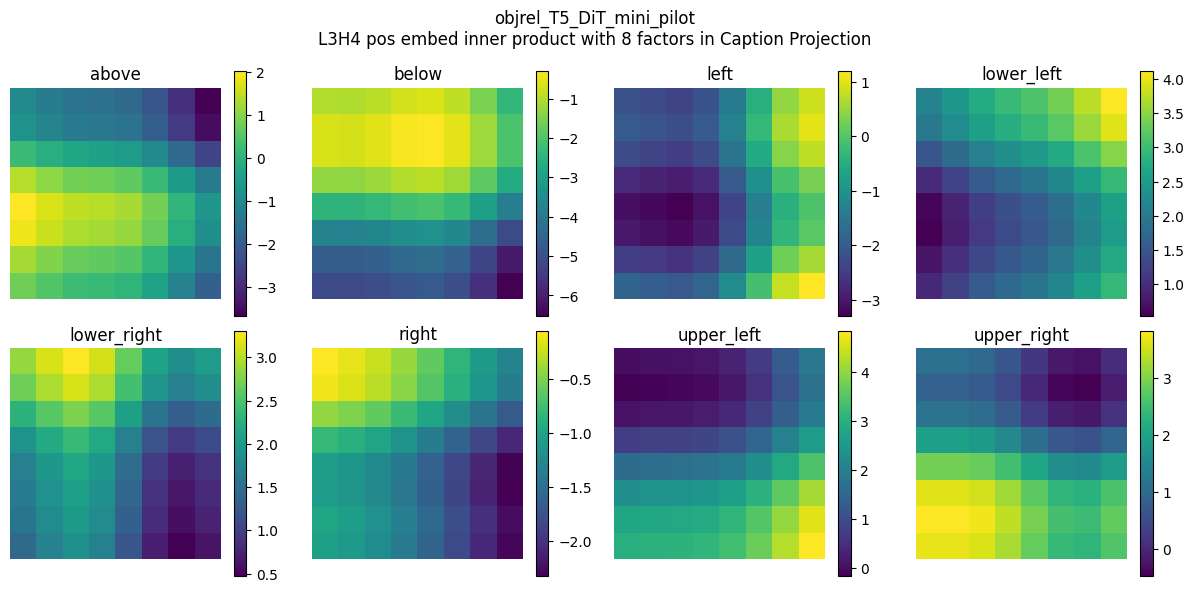

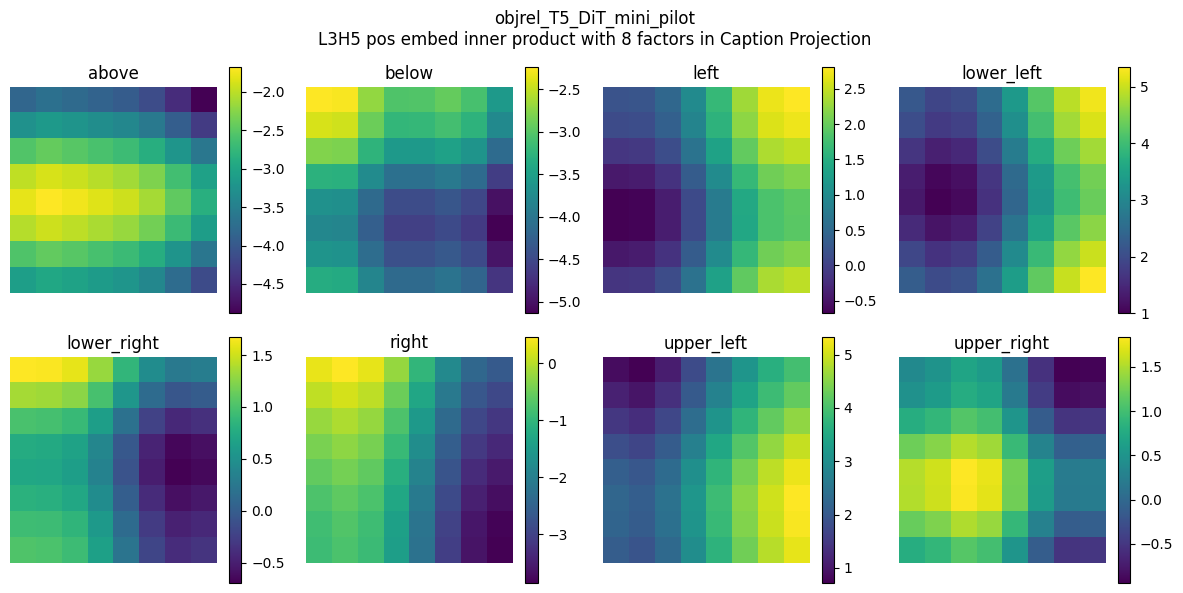

In [23]:
# Visualize the top spatial heads found from the heatmap above
# Pick heads with |cosine| > 0.7 automatically
top_heads = []
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append(row.name)  # (layer_idx, head_idx)

if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]  # fallback
    
print(f"Visualizing {len(top_heads)} top spatial heads: {top_heads}\n")
for layer_idx, head_idx in top_heads:
    inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, 
                                     effect_vecs["spatial_relationship"], 
                                     levels_names=levels_map["spatial_relationship"], 
                                     model_run_name=model_run_name, 
                                     device=device, visualize=True);

## Section F - Sanity Check Inference (Model Test)

Runs qualitative generation with cached embeddings to verify the currently loaded checkpoint/pipeline is functional before the final bias and map analyses.

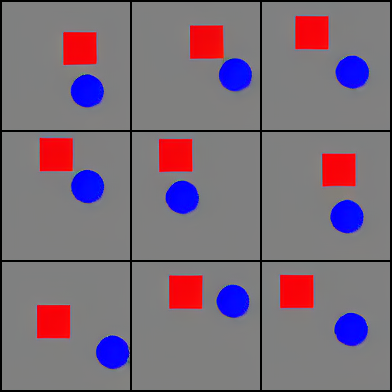

Prompt: "red square is above and to the left of blue circle" (guidance_scale=1.0, 9 seeds)


In [ ]:
# Since text_encoder=None (to save memory), we run inference manually.
test_prompt = "red square is above and to the left of blue circle"
cached = embedding_allrel_allobj[f"base::{test_prompt}"]
prompt_embeds = cached['caption_embeds'].to(dtype=compute_dtype, device=device)
prompt_mask = cached['emb_mask'].to(device=device) if 'emb_mask' in cached else torch.ones(prompt_embeds.shape[:2], dtype=torch.long, device=device)

n_imgs = 9
images = []
for seed in range(n_imgs):
    output = pipeline(
        prompt=None,
        prompt_embeds=prompt_embeds,
        prompt_attention_mask=prompt_mask,
        num_inference_steps=14,
        generator=torch.Generator(device=device).manual_seed(seed),
        guidance_scale=1.0,
        num_images_per_prompt=1,
        device=device,
    )
    images.extend(output.images)
display(pil_images_to_grid(images))
print(f'Prompt: "{test_prompt}" (guidance_scale=1.0, {n_imgs} seeds)')

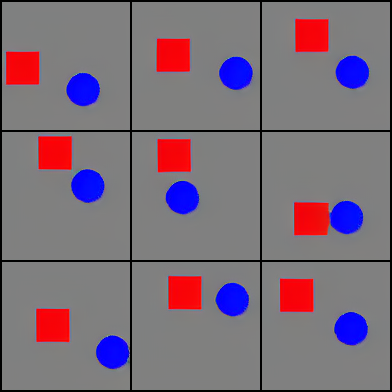

Prompt: "the red square is above and to the left of blue circle" (guidance_scale=1.0, 9 seeds)


In [ ]:
# "the" variant — uses the pre-computed "the1" embeddings
test_prompt_the = "the red square is above and to the left of blue circle"
cached_the = embedding_allrel_allobj.get(f"the1::{test_prompt_the}")
if cached_the is None:
    print(f"Prompt not in cache. Available the1 prompts:")
    for k in sorted(k for k in embedding_allrel_allobj if k.startswith("the1::"))[:5]:
        print(f"  {k}")
else:
    prompt_embeds_the = cached_the['caption_embeds'].to(dtype=compute_dtype, device=device)
    mask_the = cached_the.get('emb_mask', torch.ones(prompt_embeds_the.shape[:2], dtype=torch.long)).to(device=device)
    
    n_imgs = 9
    images_the = []
    for seed in range(n_imgs):
        out = pipeline(
            prompt=None,
            prompt_embeds=prompt_embeds_the,
            prompt_attention_mask=mask_the,
            num_inference_steps=14,
            generator=torch.Generator(device=device).manual_seed(seed),
            guidance_scale=1.0,
            num_images_per_prompt=1,
            device=device,
        )
        images_the.extend(out.images)
    display(pil_images_to_grid(images_the))
    print(f'Prompt: "{test_prompt_the}" (guidance_scale=1.0, {n_imgs} seeds)')

## Section G - Bias from Adding "the" in Prompts

Measures how adding the determiner "the" shifts projected token embeddings and relation-sensitive directions, then summarizes which factors are most affected.

In [ ]:
from easydict import EasyDict as edict
def compute_shape_wordvecs_and_project(
    pipeline, 
    prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",
    max_sequence_length=20, 
    cache_prefix="base",
):
    """Uses pre-computed cached embeddings instead of loading T5."""
    dataset_tmp = ShapesDataset(num_images=10000)
    prompt_collection_all, scene_info_collection_all = generate_all_prompt_collection(
        dataset_tmp.spatial_phrases,
        prompt_template=prompt_template,
    )
    prompt_scene_info_all_df = pd.DataFrame(scene_info_collection_all)
    prompt_scene_info_all_df["prompt"] = prompt_collection_all

    wordvec_obj1_col = []
    wordvec_obj2_col = []
    for row in prompt_scene_info_all_df.itertuples():
        tokenized = pipeline.tokenizer(
            row.prompt, max_length=max_sequence_length, padding="max_length", truncation=True, return_tensors="pt"
        )
        token_ids = tokenized['input_ids'][0]
        tokens = [pipeline.tokenizer.decode([token_id]) for token_id in token_ids]

        shape1_mask_idx = find_shape_index(tokens, row.shape1)
        shape2_mask_idx = find_shape_index(tokens, row.shape2)
        cap_embeds = embedding_allrel_allobj[f"{cache_prefix}::{row.prompt}"]['caption_embeds']
        if shape1_mask_idx is None or shape2_mask_idx is None:
            print(f"Prompt: {row.prompt}")
            print(f"Shape1 ({row.shape1}) at index: {shape1_mask_idx}")
            print(f"Shape2 ({row.shape2}) at index: {shape2_mask_idx}")
            raise ValueError("Shape index not found")
        wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
        wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
    wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
        wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    return edict({
        "prompt_scene_info_all_df": prompt_scene_info_all_df,
        "wordvec_obj1_mat": wordvec_obj1_mat,
        "wordvec_obj2_mat": wordvec_obj2_mat,
        "wordvec_obj1_mat_proj": wordvec_obj1_mat_proj,
        "wordvec_obj2_mat_proj": wordvec_obj2_mat_proj,
    })

In [ ]:
figdir_the = str(FIGURES_ROOT / "DiT_T5_the_repr_bias")
os.makedirs(figdir_the, exist_ok=True)

In [ ]:
original_wordvecs = compute_shape_wordvecs_and_project(pipeline, 
    prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}", cache_prefix="base")
the1_wordvecs = compute_shape_wordvecs_and_project(pipeline, 
    prompt_template="the {color1} {shape1} is {rel_text} {color2} {shape2}", cache_prefix="the1")
the2_wordvecs = compute_shape_wordvecs_and_project(pipeline, 
    prompt_template="{color1} {shape1} is {rel_text} the {color2} {shape2}", cache_prefix="the2")
the12_wordvecs = compute_shape_wordvecs_and_project(pipeline, 
    prompt_template="the {color1} {shape1} is {rel_text} the {color2} {shape2}", cache_prefix="the12")

In [ ]:
pkl.dump(original_wordvecs, open(join(figdir_the, "T5_shape12_wordvecs_original.pkl"), "wb"))
pkl.dump(the1_wordvecs, open(join(figdir_the, "T5_shape12_wordvecs_the1.pkl"), "wb"))
pkl.dump(the2_wordvecs, open(join(figdir_the, "T5_shape12_wordvecs_the2.pkl"), "wb"))
pkl.dump(the12_wordvecs, open(join(figdir_the, "T5_shape12_wordvecs_the12.pkl"), "wb"))

In [ ]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(original_wordvecs.wordvec_obj2_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
            #  "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

shape2, T5 embedding, caption projection
Total R2 (all features): 0.604879
Total R² (all features): 0.6049


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,249,11125.028957,2201.632767,0.197899,2201.632767,0.197899,0.333714,0.009901
1,shape2,3,2,249,11125.028957,2512.891646,0.225877,2044.452165,0.183771,0.317453,0.009901
2,color1shape1,6,5,249,11125.028957,2483.216427,0.223210,2014.776945,0.181103,0.314293,0.009901


In [ ]:
the1_pert_vecs = the1_wordvecs.wordvec_obj2_mat_proj - original_wordvecs.wordvec_obj2_mat_proj 
the1_pert_vecs_mean = the1_pert_vecs.mean(dim=0)
the2_pert_vecs = the2_wordvecs.wordvec_obj2_mat_proj - original_wordvecs.wordvec_obj2_mat_proj 
the2_pert_vecs_mean = the2_pert_vecs.mean(dim=0)
the12_pert_vecs = the12_wordvecs.wordvec_obj2_mat_proj - original_wordvecs.wordvec_obj2_mat_proj 
the12_pert_vecs_mean = the12_pert_vecs.mean(dim=0)


In [ ]:
import torch
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
# Get the spatial relationship effect vectors and the mean perturbation vector as numpy arrays
spatial_featvecs = effect_vecs["spatial_relationship"]
if isinstance(spatial_featvecs, torch.Tensor):
    spatial_featvecs = spatial_featvecs.float().cpu().numpy()
pert_vec1 = the1_pert_vecs_mean.float().cpu().numpy()[None, :]
pert_vec2 = the2_pert_vecs_mean.float().cpu().numpy()[None, :]
pert_vec12 = the12_pert_vecs_mean.float().cpu().numpy()[None, :]
# Compute cosine similarity between each effect vector and the perturbation vector
cos_sims1 = cosine_similarity(spatial_featvecs, pert_vec1)
inner_prod1 = spatial_featvecs @ pert_vec1.T
cos_sims2 = cosine_similarity(spatial_featvecs, pert_vec2)
inner_prod2 = spatial_featvecs @ pert_vec2.T
cos_sims12 = cosine_similarity(spatial_featvecs, pert_vec12)
inner_prod12 = spatial_featvecs @ pert_vec12.T
spatial_levels = levels_map["spatial_relationship"]
spatial_sim_df = pd.DataFrame({
    "spatial_relation": spatial_levels,
    "cosine[the1]": cos_sims1.flatten(),
    "dotprod[the1]": inner_prod1.flatten(),
    "cosine[the2]": cos_sims2.flatten(),
    "dotprod[the2]": inner_prod2.flatten(),
    "cosine[the12]": cos_sims12.flatten(),
    "dotprod[the12]": inner_prod12.flatten(),
})
display(spatial_sim_df)
spatial_sim_df.to_csv(join(figdir_the, "T5_shape12_the_repr_bias_spatial_sim_df.csv"), index=False)

,spatial_relation,cosine[the1],dotprod[the1],cosine[the2],dotprod[the2],cosine[the12],dotprod[the12]
0,above,-0.178899,-1.423051,-0.248096,-2.015805,-0.359328,-2.411134
1,below,0.000197,0.001524,-0.318054,-2.511031,-0.301163,-1.963604
2,left,-0.099324,-0.691181,0.327521,2.328053,0.261245,1.533568
3,lower_left,0.673712,3.649995,0.422857,2.340061,0.469685,2.146554
4,lower_right,0.124350,0.658433,-0.140675,-0.760853,0.007598,0.033940
5,right,-0.590933,-4.121827,-0.202503,-1.442773,-0.148267,-0.872397
6,upper_left,0.450449,2.384884,0.482329,2.608441,0.413127,1.845110
7,upper_right,-0.085755,-0.458777,-0.099934,-0.546093,-0.069143,-0.312037


## Section H - Cross-Attention Map Effects

Visualizes how baseline vs modified prompts/embeddings change cross-attention maps for selected heads, linking embedding shifts to spatial-attention behavior.

In [ ]:
figdir_the

'/Users/julianali/Desktop/DiffusionInterp/Figures/DiT_T5_the_repr_bias'

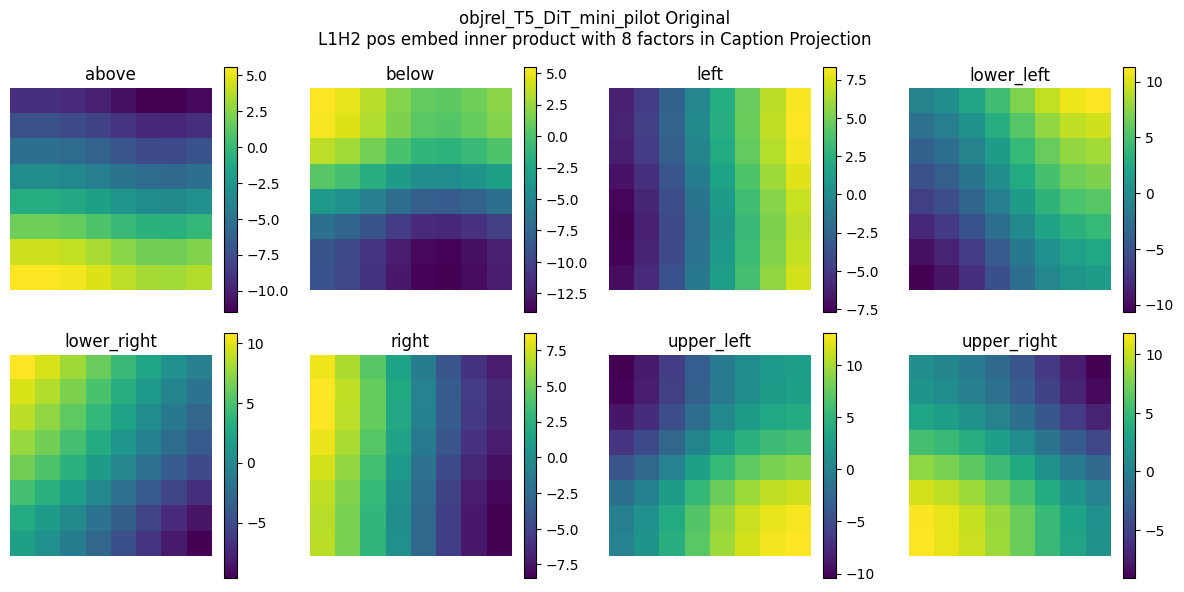

,cosine,projection,energy,template_norm,rel_name,dvec,dir_idx
0,-0.980306,-40.050791,40.855415,5.237229,above,"(0, -1)",0
1,-0.938750,-45.243696,48.195663,5.237229,below,"(0, 1)",1
2,-0.990624,-39.806029,40.182781,5.237229,left,"(-1, 0)",2
3,-0.983280,-43.282916,44.018890,5.237229,lower_left,"(-1, 1)",3
4,-0.989101,-38.901704,39.330376,5.237229,lower_right,"(1, 1)",4
5,-0.987178,-43.003701,43.562260,5.237229,right,"(1, 0)",5
6,-0.980955,-48.915269,49.864929,5.237229,upper_left,"(-1, -1)",6
7,-0.983073,-42.924650,43.663746,5.237229,upper_right,"(1, -1)",7


cosine           -0.979158
projection      -42.766094
energy           43.709259
template_norm     5.237229
dir_idx           3.500000
dtype: float64

In [ ]:
# Pick layer/head — update based on heatmap results for the mini model
layer_idx, head_idx = 1,2
inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, 
                                 effect_vecs["spatial_relationship"],
                                 levels_names=levels_map["spatial_relationship"], 
                                 model_run_name=model_run_name + " Original", 
                                 device=device, visualize=True);
align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map["spatial_relationship"])
display(align_df)
display(align_df.mean(numeric_only=True))
saveallforms(figdir_the, f"{model_run_name}_L{layer_idx}H{head_idx}_pos_embed_inprod_with_spatial_rel_proj_original", figh=fig)
align_df.to_csv(join(figdir_the, f"{model_run_name}_L{layer_idx}H{head_idx}_pos_embed_inprod_with_spatial_rel_proj_original_align_df.csv"), index=False)

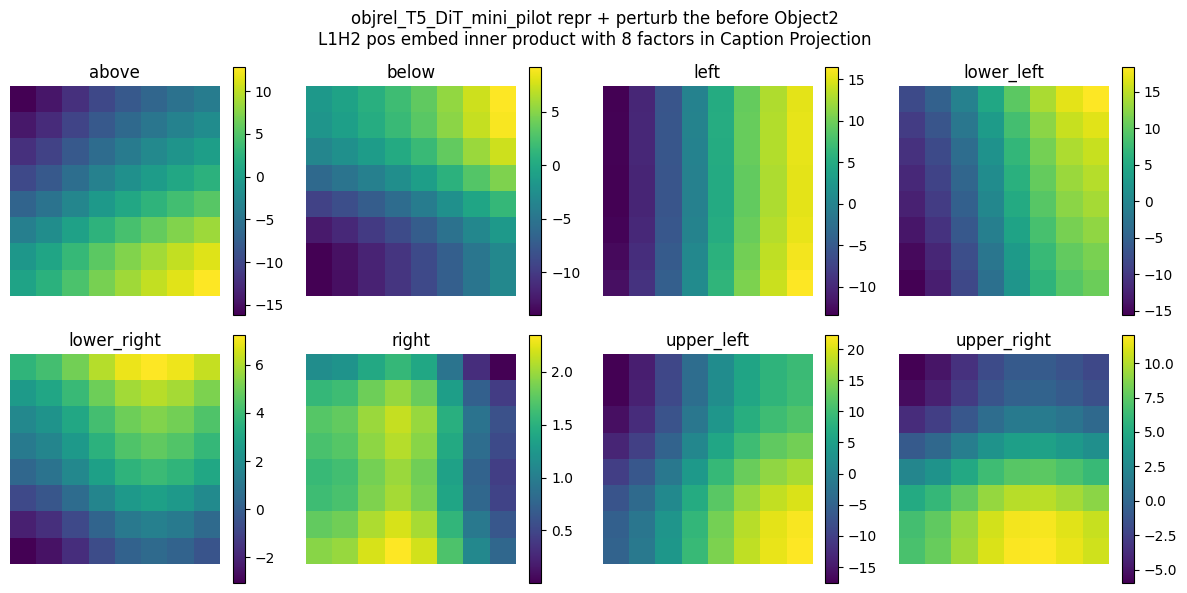

,cosine,projection,energy,template_norm,rel_name,dvec,dir_idx
0,-0.814716,-46.678741,57.294483,5.237229,above,"(0, -1)",0
1,-0.789609,-38.615746,48.904915,5.237229,below,"(0, 1)",1
2,-0.994749,-79.711630,80.132416,5.237229,left,"(-1, 0)",2
3,-0.854657,-66.813770,78.176155,5.237229,lower_left,"(-1, 1)",3
4,-0.298301,-5.997514,20.105558,5.237229,lower_right,"(1, 1)",4
5,-0.683674,-3.098099,4.531544,5.237229,right,"(1, 0)",5
6,-0.936981,-81.819462,87.322479,5.237229,upper_left,"(-1, -1)",6
7,-0.457619,-19.393798,42.379829,5.237229,upper_right,"(1, -1)",7


cosine           -0.728788
projection      -42.766095
energy           52.355919
template_norm     5.237229
dir_idx           3.500000
dtype: float64

In [ ]:
inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, 1,2, 
                                 effect_vecs["spatial_relationship"] + the2_pert_vecs_mean.detach().cpu().numpy()[None, :], 
                                 levels_names=levels_map["spatial_relationship"], 
                                 model_run_name=model_run_name + " repr + perturb the before Object2", 
                                 device=device, visualize=True);
align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map["spatial_relationship"])
display(align_df)
display(align_df.mean(numeric_only=True))
saveallforms(figdir_the, f"{model_run_name}_L{layer_idx}H{head_idx}_pos_embed_inprod_with_spatial_rel_proj_the2_vecperturb", figh=fig)
align_df.to_csv(join(figdir_the, f"{model_run_name}_L{layer_idx}H{head_idx}_pos_embed_inprod_with_spatial_rel_proj_the2_vecperturb_align_df.csv"), index=False)